# 肥胖等级多分类

**策略**：逻辑回归 / 决策树 / 随机森林 / **XGBoost** —— 均使用 **GridSearchCV**（7 折分层 CV、`scoring=f1_macro`）调参；其中树模型（含 XGBoost）在合理网格上搜索，以抬高测试集 Accuracy 与 Macro F1。

**数据**：`Obesity_Data_clean_onehot.xlsx`（已二值/one-hot 编码，本笔记不再重复编码）。

**若报错 `No module named 'sklearn'`**：请先运行**下面第一个代码格**的 `%pip install ...`（装到当前内核），再 **Restart Kernel**，然后从「import」格继续。

**用法**：从上到下依次运行；或 Kernel → Restart & Run All（需已安装依赖）。

也可在终端对**同一 Python** 执行：`pip install -r requirements.txt`。


In [9]:
# 安装依赖到「当前 Jupyter 内核」的 Python（解决 ModuleNotFoundError: sklearn）
# 只需成功运行一次；之后可注释掉本格。装完建议：Kernel → Restart Kernel
%pip install -q scikit-learn pandas openpyxl xgboost numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [55]:
import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None


In [56]:
# 全局配置
RANDOM_STATE = 100
TEST_SIZE = 0.2
CV_N_SPLITS = 7  # 折数↑：CV 估计更稳，代价是 GridSearch 更慢
RUN_REPEATED_HOLDOUT = True
N_REPEATED_HOLDOUT = 3
RUN_LR_ROUND3 = True  # 逻辑回归第三轮：在最优 C 附近加密
RUN_TREE_ROUND3 = True
TUNING_PLATEAU_EPS = 0.0005  # 略放宽「平台期」判定，避免过早放弃扩网格

SEVERITY_ORDER = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]


In [57]:
def _refine_grid_decision_tree(bp):
    """第三轮决策树：在最优参数附近加密（深度 ±2、ccp 邻域）。"""
    md = bp["max_depth"]
    if md is None:
        depth_opts = [14, 18, 22, None]
    else:
        depth_opts = sorted(
            set(
                [
                    max(4, md - 2),
                    md - 1,
                    md,
                    md + 1,
                    min(md + 2, 32),
                ]
            )
        )
    ccp = bp["ccp_alpha"]
    ccp_opts = sorted({ccp, ccp * 0.5, ccp * 2, ccp * 0.25, 0.0})[:5]
    return {
        "max_depth": depth_opts,
        "min_samples_split": [bp["min_samples_split"]],
        "min_samples_leaf": [bp["min_samples_leaf"]],
        "ccp_alpha": ccp_opts,
        "max_leaf_nodes": [bp["max_leaf_nodes"]],
    }


def _refine_grid_random_forest(bp):
    """第三轮随机森林：在 n_estimators / max_depth 上加密邻域。"""
    ne = bp["n_estimators"]
    ne_opts = sorted(
        set(
            [
                max(50, ne - 100),
                max(50, ne - 50),
                ne,
                ne + 50,
                ne + 100,
                ne + 150,
            ]
        )
    )
    md = bp["max_depth"]
    if md is None:
        md_opts = [14, 18, 22, None]
    else:
        nums = sorted(set([max(6, md - 4), md, min(md + 4, 40)]))
        md_opts = nums + [None]
    return {
        "n_estimators": ne_opts,
        "max_depth": md_opts,
        "min_samples_split": [bp["min_samples_split"]],
        "min_samples_leaf": [bp["min_samples_leaf"]],
        "max_features": [bp["max_features"]],
    }


def _stability_cv(estimator, X_train, y_train, cv_splitter):
    scores = cross_val_score(
        estimator, X_train, y_train, cv=cv_splitter,
        scoring="f1_macro", n_jobs=-1,
    )
    return {"cv_mean_macro_f1": float(np.mean(scores)), "cv_std_macro_f1": float(np.std(scores))}


def _stability_cv_xgb(xgb_model, X_train, y_train_int, cv_splitter):
    scores = cross_val_score(
        xgb_model, X_train, y_train_int, cv=cv_splitter,
        scoring="f1_macro", n_jobs=-1,
    )
    return {"cv_mean_macro_f1": float(np.mean(scores)), "cv_std_macro_f1": float(np.std(scores))}


def _repeated_holdout_macro_f1(estimator, X, y, n_times, test_size):
    scores = []
    for k in range(n_times):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size, stratify=y,
            random_state=RANDOM_STATE + 17 + k,
        )
        clf = clone(estimator)
        clf.fit(X_tr, y_tr)
        pred = clf.predict(X_te)
        scores.append(f1_score(y_te, pred, average="macro", zero_division=0))
    return float(np.mean(scores)), float(np.std(scores))


def _repeated_holdout_macro_f1_xgb(X, y, le, n_times, test_size, xgb_params):
    if XGBClassifier is None:
        return 0.0, 0.0
    scores = []
    for k in range(n_times):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size, stratify=y,
            random_state=RANDOM_STATE + 17 + k,
        )
        y_tr_i = le.transform(y_tr.astype(str))
        try:
            model = XGBClassifier(**xgb_params, use_label_encoder=False)
        except TypeError:
            model = XGBClassifier(**xgb_params)
        model.fit(X_tr, y_tr_i)
        pred_i = model.predict(X_te)
        pred_cat = le.inverse_transform(pred_i.astype(int))
        pred_cat = pd.Categorical(pred_cat, categories=SEVERITY_ORDER, ordered=True)
        scores.append(f1_score(y_te, pred_cat, average="macro", zero_division=0))
    return float(np.mean(scores)), float(np.std(scores))


def _format_best_params(best_params):
    """多行 JSON，避免 best_params 在表格里被截断看不清。"""
    if isinstance(best_params, dict):
        return json.dumps(best_params, ensure_ascii=False, indent=2, default=str)
    return str(best_params)


def _collect_result(model_name, best_params, best_cv_score, stability, y_test, y_pred, label_order):
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m = recall_score(y_test, y_pred, average="macro", zero_division=0)
    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    return {
        "model": model_name,
        "best_params": _format_best_params(best_params),
        "best_cv_macro_f1": round(best_cv_score, 5),
        "cv_mean_macro_f1": stability["cv_mean_macro_f1"],
        "cv_std_macro_f1": round(stability["cv_std_macro_f1"], 5),
        "test_accuracy": round(acc, 5),
        "test_macro_f1": round(macro_f1, 5),
        "test_weighted_f1": round(weighted_f1, 5),
        "test_precision_macro": round(prec_m, 5),
        "test_recall_macro": round(rec_m, 5),
        "test_precision_weighted": round(prec_w, 5),
        "test_recall_weighted": round(rec_w, 5),
    }


def _neighbors_none(val, pool):
    if val is None:
        return [None]
    out = {val}
    for p in pool:
        if p is None:
            continue
        if abs(p - val) <= 10:
            out.add(p)
    out.add(None)
    return list(out)


def _neighbors_int(val, pool):
    out = {int(val)}
    for p in pool:
        if abs(p - val) <= max(3, val // 2):
            out.add(p)
    return sorted(out)


## 1. 读取数据、划分特征与标签、训练/测试集

（不做 one-hot）打印列名核对；`stratify` 分层划分。


In [58]:
path = "Obesity_Data_clean_onehot.xlsx"
df = pd.read_excel(path)
print("数据集形状:", df.shape)
print("列名列表:", list(df.columns))

if "obesity_level" not in df.columns:
    raise ValueError("缺少目标列 obesity_level，请检查 Excel 列名。")
df["obesity_level"] = pd.Categorical(
    df["obesity_level"], categories=SEVERITY_ORDER, ordered=True
)

X = df.drop(columns=["obesity_level"])
y = df["obesity_level"]
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(np.int8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
print("训练集:", X_train.shape, "测试集:", X_test.shape)


数据集形状: (2076, 15)
列名列表: ['gender', 'age', 'height', 'weight', 'family_history', 'high_cal_food', 'snacking', 'smoking', 'physical_activity', 'screen_time', 'alcohol', 'obesity_level', 'transport_1', 'transport_2', 'transport_3']
训练集: (1660, 14) 测试集: (416, 14)


In [59]:
# 主指标 Macro F1；分层 CV（折数见 CV_N_SPLITS）
cv_splitter = StratifiedKFold(
    n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)
results_rows = []
model_summaries = {}


## 2. 逻辑回归（Pipeline：StandardScaler + LR，三轮 GridSearch）

在 Pipeline 上搜索；**第一轮**宽 C / 惩罚 / solver；**第二轮**在最优 C 邻域；**第三轮**在最优 C 附近对数步长加密。`max_iter` 提高以收敛。


In [60]:
pipe_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
param_grid_lr_r1 = [
    {
        "clf__C": [
            0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0,
            50.0, 100.0, 200.0,
        ],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "newton-cg", "saga"],
    },
    {
        "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
        "clf__penalty": ["l1"],
        "clf__solver": ["saga"],
    },
]
grid_lr = GridSearchCV(
    pipe_lr, param_grid_lr_r1, cv=cv_splitter,
    scoring="f1_macro", n_jobs=-1, refit=True,
)
grid_lr.fit(X_train, y_train)

best_c = grid_lr.best_params_.get("clf__C", 1.0)
best_pen = grid_lr.best_params_.get("clf__penalty", "l2")
best_sol = grid_lr.best_params_.get("clf__solver", "lbfgs")
neighbors_c = sorted(
    set(
        [
            best_c,
            best_c * 0.2,
            best_c * 0.4,
            best_c * 0.6,
            best_c * 1.5,
            best_c * 2.5,
            best_c * 4.0,
        ]
    )
)
neighbors_c = [float(min(max(c, 1e-5), 500.0)) for c in neighbors_c]

if best_pen == "l1":
    param_grid_lr_r2 = [
        {"clf__C": neighbors_c, "clf__penalty": ["l1"], "clf__solver": ["saga"]}
    ]
else:
    param_grid_lr_r2 = [
        {"clf__C": neighbors_c, "clf__penalty": ["l2"], "clf__solver": [best_sol]}
    ]
grid_lr2 = GridSearchCV(
    pipe_lr, param_grid_lr_r2, cv=cv_splitter,
    scoring="f1_macro", n_jobs=-1, refit=True,
)
grid_lr2.fit(X_train, y_train)

lr_r2_gain = grid_lr2.best_score_ - grid_lr.best_score_
if lr_r2_gain < TUNING_PLATEAU_EPS:
    print(
        f"[逻辑回归] 第二轮相对第一轮 CV(Macro F1) 提升 {lr_r2_gain:.5f}，"
        "已较小；继续第三轮仍可能微调。"
    )
final_lr = grid_lr2 if grid_lr2.best_score_ >= grid_lr.best_score_ else grid_lr

if RUN_LR_ROUND3:
    bpc = final_lr.best_params_.get("clf__C", 1.0)
    bpen = final_lr.best_params_.get("clf__penalty", "l2")
    bsol = final_lr.best_params_.get("clf__solver", "lbfgs")
    dense_c = sorted(
        set(
            [bpc * (0.75 ** i) for i in range(-4, 5)]
            + [bpc * 0.9, bpc * 1.1, bpc * 0.85, bpc * 1.15]
        )
    )
    dense_c = [float(min(max(c, 1e-5), 500.0)) for c in dense_c]
    if bpen == "l1":
        grid_lr3 = GridSearchCV(
            pipe_lr,
            [{"clf__C": dense_c, "clf__penalty": ["l1"], "clf__solver": ["saga"]}],
            cv=cv_splitter,
            scoring="f1_macro",
            n_jobs=-1,
            refit=True,
        )
    else:
        grid_lr3 = GridSearchCV(
            pipe_lr,
            [
                {
                    "clf__C": dense_c,
                    "clf__penalty": ["l2"],
                    "clf__solver": [bsol],
                }
            ],
            cv=cv_splitter,
            scoring="f1_macro",
            n_jobs=-1,
            refit=True,
        )
    grid_lr3.fit(X_train, y_train)
    cv_before_lr3 = final_lr.best_score_
    if grid_lr3.best_score_ > cv_before_lr3:
        final_lr = grid_lr3
        print(
            f"[逻辑回归] 第三轮 CV(Macro F1) 从 {cv_before_lr3:.5f} 提升至 {grid_lr3.best_score_:.5f}。"
        )
    else:
        print(
            f"[逻辑回归] 第三轮未超过 {cv_before_lr3:.5f}，保留上一轮最优。"
        )

y_pred_lr = final_lr.predict(X_test)
stab_lr = _stability_cv(final_lr.best_estimator_, X_train, y_train, cv_splitter)
row_lr = _collect_result(
    "Logistic Regression (Pipeline, Grid 多轮)",
    final_lr.best_params_,
    final_lr.best_score_,
    stab_lr,
    y_test,
    y_pred_lr,
    SEVERITY_ORDER,
)
results_rows.append(row_lr)
model_summaries["lr"] = row_lr
print("逻辑回归 best CV macro F1:", final_lr.best_score_)


[逻辑回归] 第三轮 CV(Macro F1) 从 0.96005 提升至 0.96005。
逻辑回归 best CV macro F1: 0.960051344193379


## 3. 决策树（未标准化；多轮 GridSearch，扩大深度/叶/剪枝搜索）


In [61]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
param_grid_dt_r1 = {
    "max_depth": [6, 8, 10, 12, 15, 18, 20, 24, None],
    "min_samples_split": [2, 3, 5, 8, 10, 15],
    "min_samples_leaf": [1, 2, 3, 4, 6],
    "ccp_alpha": [0.0, 1e-5, 5e-5, 0.0001, 0.0005, 0.001],
    "max_leaf_nodes": [None, 64, 128, 256],
}
grid_dt = GridSearchCV(
    dt, param_grid_dt_r1, cv=cv_splitter,
    scoring="f1_macro", n_jobs=-1, refit=True,
)
grid_dt.fit(X_train, y_train)

bp = grid_dt.best_params_
param_grid_dt_r2 = {
    "max_depth": _neighbors_none(
        bp["max_depth"],
        [6, 8, 10, 12, 15, 18, 20, 24, None],
    ),
    "min_samples_split": _neighbors_int(
        bp["min_samples_split"], [2, 3, 5, 8, 10, 15, 20]
    ),
    "min_samples_leaf": _neighbors_int(bp["min_samples_leaf"], [1, 2, 3, 4, 6, 8]),
    "ccp_alpha": sorted(
        set([bp["ccp_alpha"], bp["ccp_alpha"] * 0.3, bp["ccp_alpha"] * 3])
    ),
    "max_leaf_nodes": [bp["max_leaf_nodes"]],
}
grid_dt2 = GridSearchCV(
    dt, param_grid_dt_r2, cv=cv_splitter,
    scoring="f1_macro", n_jobs=-1, refit=True,
)
grid_dt2.fit(X_train, y_train)

dt_r2_gain = grid_dt2.best_score_ - grid_dt.best_score_
if dt_r2_gain < TUNING_PLATEAU_EPS:
    print(
        f"[决策树] 第二轮相对第一轮 CV 提升 {dt_r2_gain:.5f}，继续加网格收益可能有限。"
    )

final_dt = grid_dt2 if grid_dt2.best_score_ >= grid_dt.best_score_ else grid_dt
if RUN_TREE_ROUND3:
    bp2 = final_dt.best_params_
    param_grid_dt_r3 = _refine_grid_decision_tree(bp2)
    cv_before_r3 = final_dt.best_score_
    grid_dt3 = GridSearchCV(
        dt, param_grid_dt_r3, cv=cv_splitter,
        scoring="f1_macro", n_jobs=-1, refit=True,
    )
    grid_dt3.fit(X_train, y_train)
    if grid_dt3.best_score_ > cv_before_r3:
        final_dt = grid_dt3
        print(
            f"[决策树] 第三轮 CV(Macro F1) 从 {cv_before_r3:.5f} 提升至 {grid_dt3.best_score_:.5f}。"
        )
    else:
        print(
            f"[决策树] 第三轮未超过 {cv_before_r3:.5f}，保留上一轮最优。"
        )

y_pred_dt = final_dt.predict(X_test)
stab_dt = _stability_cv(final_dt.best_estimator_, X_train, y_train, cv_splitter)
row_dt = _collect_result(
    "Decision Tree (Grid 多轮)",
    final_dt.best_params_,
    final_dt.best_score_,
    stab_dt,
    y_test,
    y_pred_dt,
    SEVERITY_ORDER,
)
results_rows.append(row_dt)
model_summaries["dt"] = row_dt
print("决策树 best CV macro F1:", final_dt.best_score_)


[决策树] 第二轮相对第一轮 CV 提升 0.00000，继续加网格收益可能有限。
[决策树] 第三轮未超过 0.93404，保留上一轮最优。
决策树 best CV macro F1: 0.9340356598476617


## 4. 随机森林（未标准化；多轮 GridSearch，扩大树数/深度/特征子集）


In [62]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")
param_grid_rf_r1 = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [8, 12, 16, 18, 24, 30, None],
    "min_samples_split": [2, 3, 5, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", "log2", 0.25, 0.35, 0.5, 0.65],
}
grid_rf = GridSearchCV(
    rf, param_grid_rf_r1, cv=cv_splitter,
    scoring="f1_macro", n_jobs=-1, refit=True,
)
grid_rf.fit(X_train, y_train)

bp_rf = grid_rf.best_params_
param_grid_rf_r2 = {
    "n_estimators": _neighbors_int(
        bp_rf["n_estimators"],
        [80, 120, 150, 200, 250, 300, 350, 400, 450, 500],
    ),
    "max_depth": _neighbors_none(
        bp_rf["max_depth"],
        [8, 12, 16, 18, 20, 24, 30, None],
    ),
    "min_samples_split": [bp_rf["min_samples_split"]],
    "min_samples_leaf": [bp_rf["min_samples_leaf"]],
    "max_features": [bp_rf["max_features"]],
}
grid_rf2 = GridSearchCV(
    rf, param_grid_rf_r2, cv=cv_splitter,
    scoring="f1_macro", n_jobs=-1, refit=True,
)
grid_rf2.fit(X_train, y_train)

rf_r2_gain = grid_rf2.best_score_ - grid_rf.best_score_
if rf_r2_gain < TUNING_PLATEAU_EPS:
    print(
        f"[随机森林] 第二轮相对第一轮 CV 提升 {rf_r2_gain:.5f}，再扩大搜索收益可能有限。"
    )

final_rf = grid_rf2 if grid_rf2.best_score_ >= grid_rf.best_score_ else grid_rf
if RUN_TREE_ROUND3:
    bp2_rf = final_rf.best_params_
    param_grid_rf_r3 = _refine_grid_random_forest(bp2_rf)
    cv_rf_before_r3 = final_rf.best_score_
    grid_rf3 = GridSearchCV(
        rf, param_grid_rf_r3, cv=cv_splitter,
        scoring="f1_macro", n_jobs=-1, refit=True,
    )
    grid_rf3.fit(X_train, y_train)
    if grid_rf3.best_score_ > cv_rf_before_r3:
        final_rf = grid_rf3
        print(
            f"[随机森林] 第三轮 CV(Macro F1) 从 {cv_rf_before_r3:.5f} 提升至 {grid_rf3.best_score_:.5f}。"
        )
    else:
        print(
            f"[随机森林] 第三轮未超过 {cv_rf_before_r3:.5f}，保留上一轮最优。"
        )

y_pred_rf = final_rf.predict(X_test)
stab_rf = _stability_cv(final_rf.best_estimator_, X_train, y_train, cv_splitter)
row_rf = _collect_result(
    "Random Forest (Grid 多轮)",
    final_rf.best_params_,
    final_rf.best_score_,
    stab_rf,
    y_test,
    y_pred_rf,
    SEVERITY_ORDER,
)
results_rows.append(row_rf)
model_summaries["rf"] = row_rf
print("随机森林 best CV macro F1:", final_rf.best_score_)


[随机森林] 第三轮未超过 0.95710，保留上一轮最优。
随机森林 best CV macro F1: 0.9570967225559646


## 5. XGBoost（GridSearchCV）

在整数编码标签 `y_train_xgb` 上搜索 `n_estimators` / `max_depth` / `learning_rate` / `min_child_weight` / `subsample` / `colsample_bytree`；固定 `random_state`、`eval_metric='mlogloss'`、`n_jobs=1`（单树内线程）及兼容的 `use_label_encoder`。`GridSearchCV` 使用与其它模型相同的 `cv_splitter` 与 `f1_macro`。


In [63]:
row_xgb = None
y_pred_xgb = None
le = None
_xgb_kw = None

if XGBClassifier is None:
    print("未安装 xgboost，跳过 XGBoost。")
else:
    le = LabelEncoder()
    le.fit(SEVERITY_ORDER)
    y_train_xgb = le.transform(y_train.astype(str))

    _xgb_fixed = dict(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=1,
    )
    try:
        xgb_est = XGBClassifier(**_xgb_fixed, use_label_encoder=False)
    except TypeError:
        xgb_est = XGBClassifier(**_xgb_fixed)

    param_grid_xgb = {
        "n_estimators": [200, 300],
        "max_depth": [6, 8],
        "learning_rate": [0.05, 0.1],
        "min_child_weight": [1, 3],
        "subsample": [0.9, 1.0],
        "colsample_bytree": [0.9, 1.0],
    }

    grid_xgb = GridSearchCV(
        xgb_est,
        param_grid_xgb,
        cv=cv_splitter,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
    )
    print("XGBoost GridSearchCV 训练中（7 折 × 网格，可能需数分钟）…")
    grid_xgb.fit(X_train, y_train_xgb)
    xgb = grid_xgb.best_estimator_
    _xgb_kw = {**_xgb_fixed, **grid_xgb.best_params_}

    y_pred_xgb_idx = xgb.predict(X_test)
    y_pred_xgb = le.inverse_transform(y_pred_xgb_idx.astype(int))
    y_pred_xgb = pd.Categorical(
        y_pred_xgb, categories=SEVERITY_ORDER, ordered=True
    )
    stab_xgb = _stability_cv_xgb(xgb, X_train, y_train_xgb, cv_splitter)
    row_xgb = _collect_result(
        "XGBoost (GridSearchCV)",
        {**_xgb_kw, "note": "GridSearchCV 最优参数 + 上列固定项"},
        grid_xgb.best_score_,
        stab_xgb,
        y_test,
        y_pred_xgb,
        SEVERITY_ORDER,
    )
    results_rows.append(row_xgb)
    model_summaries["xgb"] = row_xgb

    print("Best params:", grid_xgb.best_params_)
    print("Best CV macro F1 (GridSearchCV):", float(grid_xgb.best_score_))
    print("XGBoost 已训练。主要指标：")
    for k in (
        "best_cv_macro_f1",
        "cv_mean_macro_f1",
        "cv_std_macro_f1",
        "test_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
    ):
        print(f"  {k}: {row_xgb[k]}")


XGBoost 已训练。主要指标：
  best_cv_macro_f1: 0.96191
  cv_mean_macro_f1: 0.9619117212596926
  cv_std_macro_f1: 0.00735
  test_accuracy: 0.96394
  test_macro_f1: 0.96229
  test_weighted_f1: 0.96384


## 6. 结果汇总表（DataFrame）

主表仅含 **Accuracy、Macro F1、Weighted F1、CV std、Macro Recall** 与 **best_params**（多行完整显示）；另附 **Weighted Recall / Macro Precision / Weighted Precision**。混淆矩阵见 **§8 热力图**。


In [68]:
# 各模型完整指标（测试集）：Accuracy、Macro/Weighted F1、CV std、Macro/Weighted Recall/Precision
from IPython.display import display

summary_df = pd.DataFrame(results_rows)
SUMMARY_COLS = [
    "model",
    "best_params",
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "cv_std_macro_f1",
    "test_recall_macro",
]
SUMMARY_COLS_RENAME = {
    "test_accuracy": "Accuracy",
    "test_macro_f1": "Macro F1（主指标）",
    "test_weighted_f1": "Weighted F1",
    "cv_std_macro_f1": "CV std",
    "test_recall_macro": "Macro Recall",
}
summary_display = summary_df[SUMMARY_COLS].rename(columns=SUMMARY_COLS_RENAME)
print(
    "\n========== 各模型结果汇总（仅列：Accuracy / Macro F1 / Weighted F1 / CV std / Macro Recall；best_params 完整）=========="
)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
display(summary_display)

print(
    "\n---------- 其余测试集指标（Weighted Recall / Macro Precision / Weighted Precision）----------"
)
extra_rename = {
    "test_recall_weighted": "Weighted Recall",
    "test_precision_macro": "Macro Precision",
    "test_precision_weighted": "Weighted Precision",
}
extra_display = summary_df[["model"] + list(extra_rename.keys())].rename(columns=extra_rename)
display(extra_display)



========== 各模型结果汇总（仅列：Accuracy / Macro F1 / Weighted F1 / CV std / Macro Recall；best_params 完整）==========


,model,best_params,Accuracy,Macro F1（主指标）,Weighted F1,CV std,Macro Recall
0,"Logistic Regression (Pipeline, Grid 多轮)","{\n ""clf__C"": 281.25,\n ""clf__penalty"": ""l2"",\n ""clf__solver"": ""newton-cg""\n}",0.95673,0.95574,0.95682,0.01245,0.95660
1,Decision Tree (Grid 多轮),"{\n ""ccp_alpha"": 0.0,\n ""max_depth"": 10,\n ""max_leaf_nodes"": null,\n ""min_samples_leaf"": 1,\n ""min_samples_split"": 3\n}",0.92788,0.92626,0.92846,0.01285,0.92642
2,Random Forest (Grid 多轮),"{\n ""max_depth"": 16,\n ""max_features"": 0.65,\n ""min_samples_leaf"": 1,\n ""min_samples_split"": 2,\n ""n_estimators"": 150\n}",0.95433,0.95342,0.95452,0.00793,0.95371
3,"XGBoost (与 model1 一致, 默认超参)","{\n ""random_state"": 100,\n ""eval_metric"": ""mlogloss"",\n ""n_jobs"": 1,\n ""note"": ""其余为 xgboost 库默认""\n}",0.96394,0.96229,0.96384,0.00735,0.96246



---------- 其余测试集指标（Weighted Recall / Macro Precision / Weighted Precision）----------


,model,Weighted Recall,Macro Precision,Weighted Precision
0,"Logistic Regression (Pipeline, Grid 多轮)",0.95673,0.95524,0.95730
1,Decision Tree (Grid 多轮),0.92788,0.92730,0.93023
2,Random Forest (Grid 多轮),0.95433,0.95362,0.95520
3,"XGBoost (与 model1 一致, 默认超参)",0.96394,0.96260,0.96418


## 7. 重复分层划分稳定性（测试 Macro F1 的 mean / std）


In [65]:
if RUN_REPEATED_HOLDOUT:
    print(
        f"========== 重复分层划分稳定性（{N_REPEATED_HOLDOUT} 次）=========="
    )
    for label, est in [
        ("LogisticRegression", final_lr.best_estimator_),
        ("DecisionTree", final_dt.best_estimator_),
        ("RandomForest", final_rf.best_estimator_),
    ]:
        mu, sigma = _repeated_holdout_macro_f1(
            est, X, y, n_times=N_REPEATED_HOLDOUT, test_size=TEST_SIZE
        )
        print(f"  {label}: mean={mu:.5f}, std={sigma:.5f}")
    if row_xgb is not None and le is not None and _xgb_kw is not None:
        mu, sigma = _repeated_holdout_macro_f1_xgb(
            X, y, le, n_times=N_REPEATED_HOLDOUT,
            test_size=TEST_SIZE, xgb_params=_xgb_kw,
        )
        print(f"  XGBoost: mean={mu:.5f}, std={sigma:.5f}")
else:
    print("已关闭 RUN_REPEATED_HOLDOUT，跳过本步。")


========== 重复分层划分稳定性（3 次）==========
  LogisticRegression: mean=0.96245, std=0.00197
  DecisionTree: mean=0.92507, std=0.01531
  RandomForest: mean=0.96920, std=0.00739
  XGBoost: mean=0.96791, std=0.00278


## 8. 混淆矩阵（热力图）与 classification_report


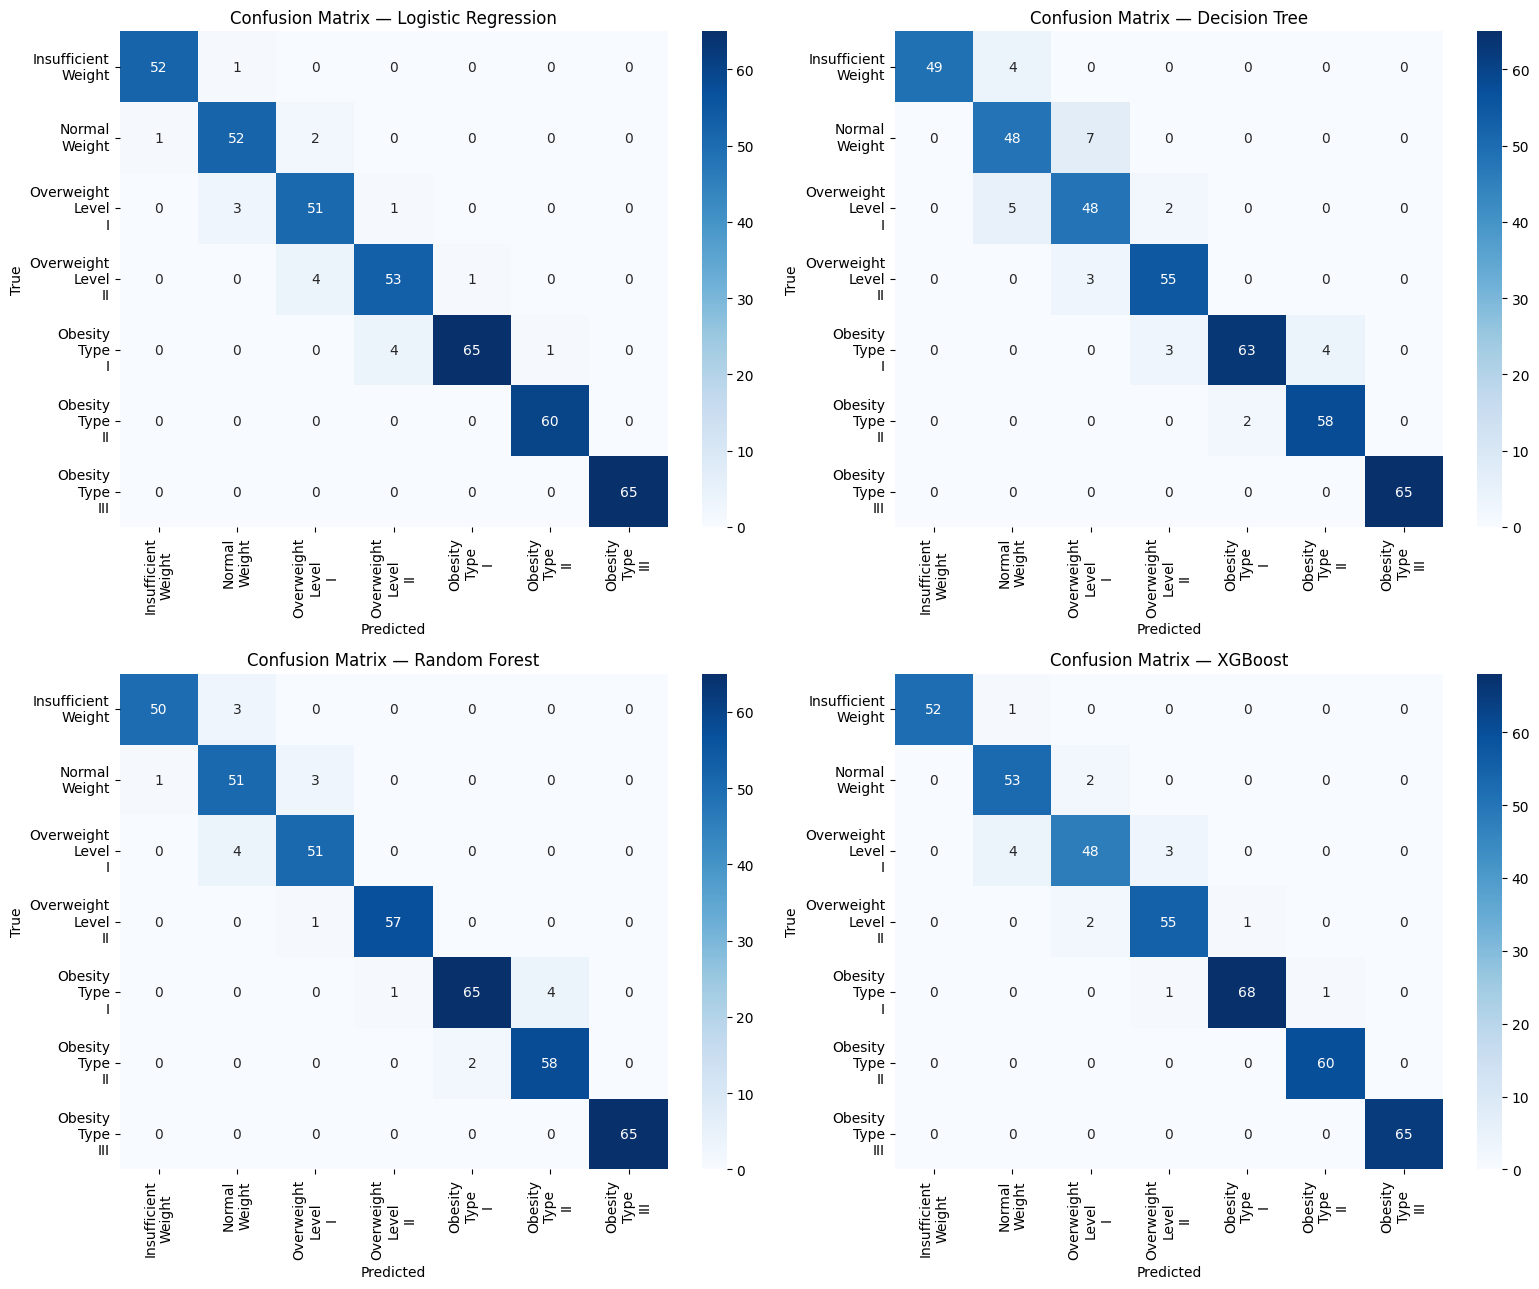


========== Classification Report（各模型，测试集）==========

----- LogisticRegression -----
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        53
      Normal_Weight       0.93      0.95      0.94        55
 Overweight_Level_I       0.89      0.93      0.91        55
Overweight_Level_II       0.91      0.91      0.91        58
     Obesity_Type_I       0.98      0.93      0.96        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65

           accuracy                           0.96       416
          macro avg       0.96      0.96      0.96       416
       weighted avg       0.96      0.96      0.96       416


----- DecisionTree -----
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.92      0.96        53
      Normal_Weight       0.84      0.87      0.86        55
 Overweight_Level_I       0.83 

In [66]:
label_short = [s.replace("_", "\n") for s in SEVERITY_ORDER]
cm_items = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
]
if row_xgb is not None and y_pred_xgb is not None:
    cm_items.append(("XGBoost", y_pred_xgb))

n_cm = len(cm_items)
ncols = 2
nrows = int(np.ceil(n_cm / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6.5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, (name, pred) in zip(axes, cm_items):
    cm = confusion_matrix(y_test, pred, labels=SEVERITY_ORDER)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_short,
        yticklabels=label_short,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {name}")
for j in range(n_cm, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

print(
    "\n========== Classification Report（各模型，测试集）=========="
)
for name, pred in [
    ("LogisticRegression", y_pred_lr),
    ("DecisionTree", y_pred_dt),
    ("RandomForest", y_pred_rf),
]:
    print(f"\n----- {name} -----")
    print(
        classification_report(
            y_test, pred, labels=SEVERITY_ORDER, zero_division=0
        )
    )

if row_xgb is not None and y_pred_xgb is not None:
    print("\n----- XGBoost -----")
    print(
        classification_report(
            y_test, y_pred_xgb, labels=SEVERITY_ORDER, zero_division=0
        )
    )


## 9. 模型选择建议（预测最优 vs 教学解释）


In [67]:
print("========== 模型选择建议 ==========")
candidates = [
    ("Logistic Regression", row_lr["test_macro_f1"], row_lr),
    ("Decision Tree", row_dt["test_macro_f1"], row_dt),
    ("Random Forest", row_rf["test_macro_f1"], row_rf),
]
if row_xgb is not None:
    candidates.append(("XGBoost", row_xgb["test_macro_f1"], row_xgb))

pred_best = max(candidates, key=lambda x: x[1])
print(
    f"【Predictive best】测试 Macro F1: {pred_best[0]}, F1={pred_best[1]:.5f}"
)
if pred_best[0] == "XGBoost":
    print("（XGBoost 常为强 benchmark；作业中可如实报告。）")

tree_rows = [("Decision Tree", row_dt), ("Random Forest", row_rf)]
edu_name = max(
    tree_rows,
    key=lambda t: (t[1]["test_macro_f1"], -t[1]["cv_std_macro_f1"]),
)[0]
print(
    f"【Educationally preferable】推荐: {edu_name} 或决策树（规则直观）；"
    "随机森林可看特征重要性。"
)
print(
    "最优模型不一定只看分数最高：分数接近时可选更稳定（CV std 更小）、更易讲解的模型。"
)
print(
    f"若多轮 GridSearch 提升已低于约 {TUNING_PLATEAU_EPS}，可写明「继续扩大网格收益递减」。"
)


========== 模型选择建议 ==========
【Predictive best】测试 Macro F1: XGBoost, F1=0.96229
（XGBoost 常为强 benchmark；作业中可如实报告。）
【Educationally preferable】推荐: Random Forest 或决策树（规则直观）；随机森林可看特征重要性。
最优模型不一定只看分数最高：分数接近时可选更稳定（CV std 更小）、更易讲解的模型。
若多轮 GridSearch 提升已低于约 0.0005，可写明「继续扩大网格收益递减」。
